# NASA Milling: my learning notebook, with reading notes

Project by Songjiang Cai. This reading edition follows the supplied `Mill_phase_2_Fixed.ipynb` cell by cell. Its variables, loops, commented-out experiments and original markdown notes are retained. The untouched supplied file is also in this folder.

**整理说明 / Editorial notes:** every explanatory cell added during publication preparation is marked. Necessary code edits are recorded in cell metadata and in `docs/SOURCE_CODE_GUIDE_ZH.md`. Code added after the original notebook is labelled as a publication addition assisted by ChatGPT.

The supplied file already carries restoration metadata from an earlier pasted Colab export. The untouched copy preserves that file exactly; it cannot establish the original whitespace before that restoration.

The calculations describe Case 1 and in-sample fits. Independent validation and a combined model remain future work. Personal reflection is left for the project author.


## 整理说明 / Editorial note: data location

This setup cell is added for running the same notebook in Colab or locally. In Colab, the default is the author's previous Drive location. Locally, put the raw NASA `mill.mat` in `data/`. Change `DATA_PATH` here if your file is somewhere else. The original feature extraction below does not import `src/analysis.py`.


In [1]:
# [整理补充 / Added setup] No analysis is performed in this cell.
from pathlib import Path

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

ROOT = next((p for p in [Path.cwd(), Path.cwd().parent,
                        Path('/content/milling-project'),
                        Path('/content/nasa-milling-tool-wear')]
             if (p / 'notebooks' / 'Mill_phase_2_Fixed.ipynb').is_file()), Path.cwd())
DATA_PATH = (Path('/content/drive/MyDrive/mill.mat') if IN_COLAB
             else ROOT / 'data' / 'mill.mat')
print('Data path:', DATA_PATH)


Data path: /workspace/scratch/11e369807ea7/deliverables/nasa-milling-tool-wear/data/mill.mat


## 整理说明 / Editorial note: original Drive cell

The original Drive-mounting lines remain below, wrapped so a local Python environment can skip this Colab-specific action.

In [2]:
# [整理修正 / Runtime adaptation] Skip Drive mounting outside Colab.
if IN_COLAB:
    from google.colab import drive
    import shutil

    drive.mount('/content/drive')


## 整理说明 / Editorial note: loading the same data

Only the hard-coded path is changed to `DATA_PATH`. The repeated data-inspection cell is retained so the learning sequence stays visible.

In [3]:
# [整理修正 / Path only] Use the configurable DATA_PATH.
from scipy.io import loadmat

file = loadmat(DATA_PATH)
mill = file['mill']


In [4]:
# [整理修正 / Path only] Use the configurable DATA_PATH.
from scipy.io import loadmat
file = loadmat(DATA_PATH)
print(file.keys())
import numpy as np


dict_keys(['__header__', '__version__', '__globals__', 'mill'])


In [5]:
mill = file["mill"]
print(type(mill))
print(mill.shape)
print(mill.dtype.names)


<class 'numpy.ndarray'>
(1, 167)
('case', 'run', 'VB', 'time', 'DOC', 'feed', 'material', 'smcAC', 'smcDC', 'vib_table', 'vib_spindle', 'AE_table', 'AE_spindle')


## 整理说明 / Editorial note: the original window

The following `t_s` and `mask_cut` calculation is unchanged. Its physical seconds have not been verified. Waveform axes therefore say **assumed time coordinate**. Publication figures later use sample indices or dataset units. No verified sampling rate is claimed.

In [6]:
t_s = np.arange(9000)*36/9000
mask_cut = (t_s>10) & (t_s<25)


## 整理说明 / Editorial note: filtering and record numbers

This is the original loop, including the zero-wear record. Here `number` is the global record position `i+1`. In this Case 1 subset it matches the stored per-case `run` field; that equality is checked later. This should be rechecked before applying the same labels to other cases.

case= [[1]] VB= 0 run number= 1
case= [[1]] VB= 0.11 run number= 4
case= [[1]] VB= 0.2 run number= 6
case= [[1]] VB= 0.24 run number= 7
case= [[1]] VB= 0.29 run number= 8
case= [[1]] VB= 0.28 run number= 9
case= [[1]] VB= 0.29 run number= 10
case= [[1]] VB= 0.38 run number= 11
case= [[1]] VB= 0.4 run number= 12
case= [[1]] VB= 0.43 run number= 13
case= [[1]] VB= 0.45 run number= 14
case= [[1]] VB= 0.5 run number= 15
case= [[1]] VB= 0.44 run number= 17


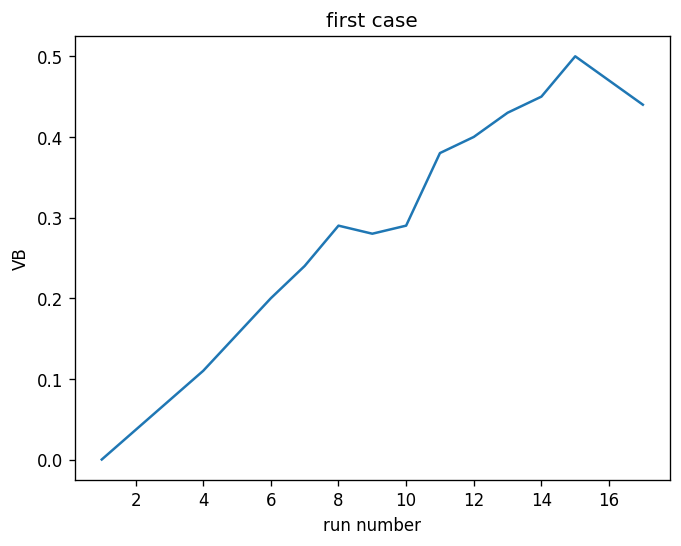

In [7]:
import matplotlib.pyplot as plt
VB_work = []
number = []
for i in range(167):
  run = mill[0,i]
  state = (not np.isnan(run["VB"].item()) and run["case"].item()== 1)

  if state:
    print("case=",run["case"],"VB=",run["VB"].item(),"run number=",i+1)
    VB_work.append(run["VB"].item())
    number.append(i+1)

plt.plot(number,VB_work)
plt.xlabel("run number")
plt.ylabel("VB")
plt.title("first case")
plt.show()


VB / Run


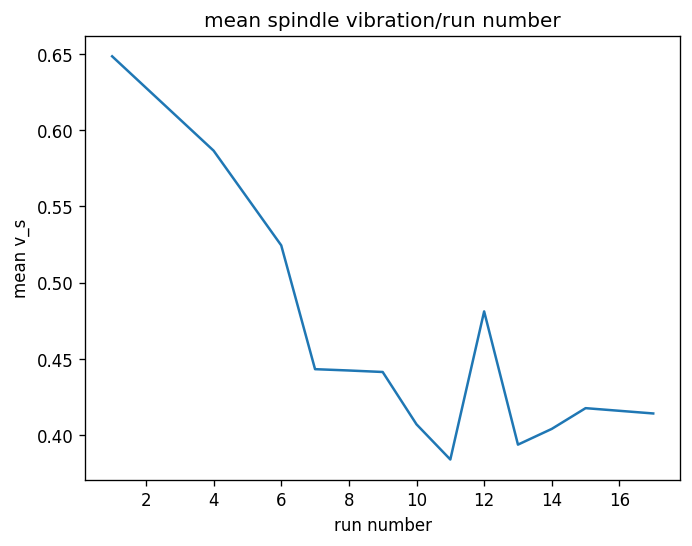

In [8]:
vib_spindle_cut_mean = []
for i in number:
  run = mill[0,i-1]
  vib_spindle_mean = np.mean(run["vib_spindle"][mask_cut])
  vib_spindle_cut_mean.append(vib_spindle_mean)

plt.plot(number,vib_spindle_cut_mean)
plt.title("mean spindle vibration/run number")
plt.ylabel("mean v_s")
plt.xlabel("run number")
plt.show()


the mean v_s/number figure without nan


## 整理说明 / Editorial note: missing VB labels

This original plot also includes records whose VB is missing. The vibration signals themselves are still present. The original variable name ending in `_nan` is kept; it does not mean that the signal values are all NaN.

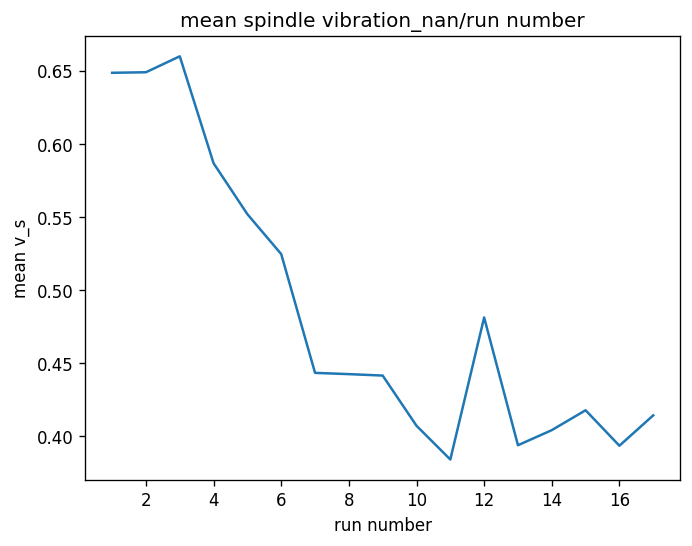

In [9]:
vib_spindle_cut_mean_nan = []
number_nan = []
for i in range(17):
  run = mill[0,i]
  vib_spindle_mean = np.mean(run["vib_spindle"][mask_cut])
  vib_spindle_cut_mean_nan.append(vib_spindle_mean)
  number_nan.append(i+1)

plt.plot(number_nan,vib_spindle_cut_mean_nan)
plt.title("mean spindle vibration_nan/run number")
plt.ylabel("mean v_s")
plt.xlabel("run number")
plt.show()


the vib with nan


run 12 vb= 0.4


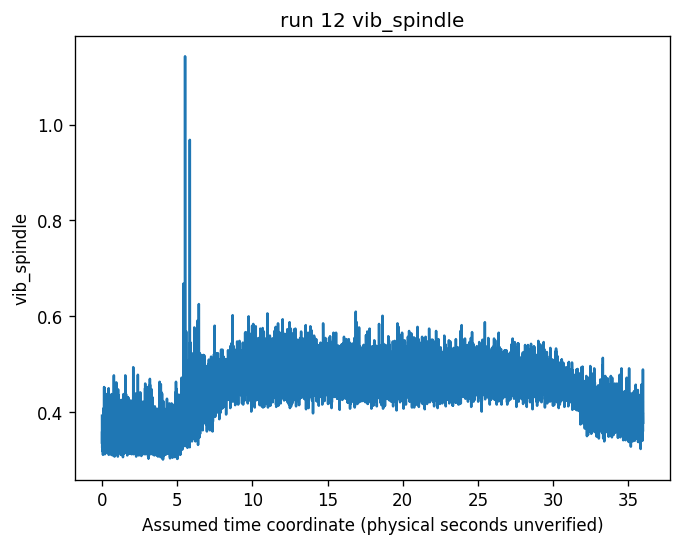

In [10]:
mill_12 = mill[0,11]["vib_spindle"]
print("run 12 vb=",mill[0,11]["VB"].item())

plt.plot(t_s,mill_12)
plt.title("run 12 vib_spindle")
plt.xlabel("Assumed time coordinate (physical seconds unverified)")
plt.ylabel("vib_spindle")
plt.show()


In [11]:
mean_mill_12_cut = np.mean(mill_12[mask_cut])
print(mean_mill_12_cut)


0.4811211375116698


run-12 vib_spindle abnormal high


run 11 vb= 0.38


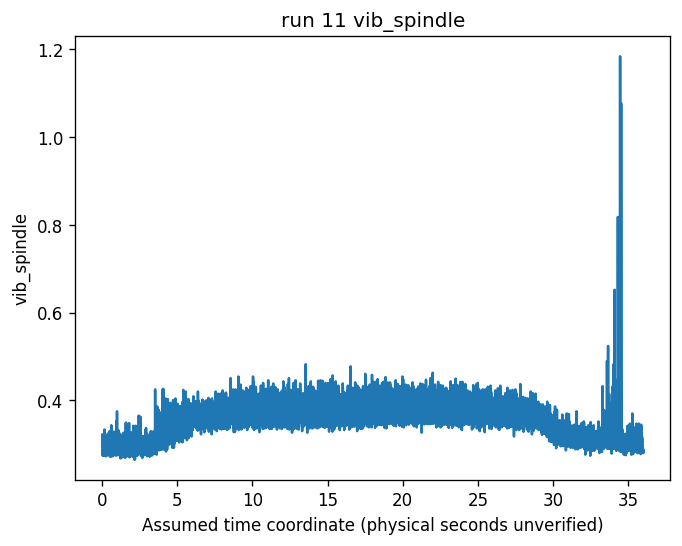

In [12]:
mill_11 = mill[0,10]["vib_spindle"]
print("run 11 vb=",mill[0,10]["VB"].item())

plt.plot(t_s,mill_11)
plt.title("run 11 vib_spindle")
plt.xlabel("Assumed time coordinate (physical seconds unverified)")
plt.ylabel("vib_spindle")
plt.show()


run 13 vb= 0.43


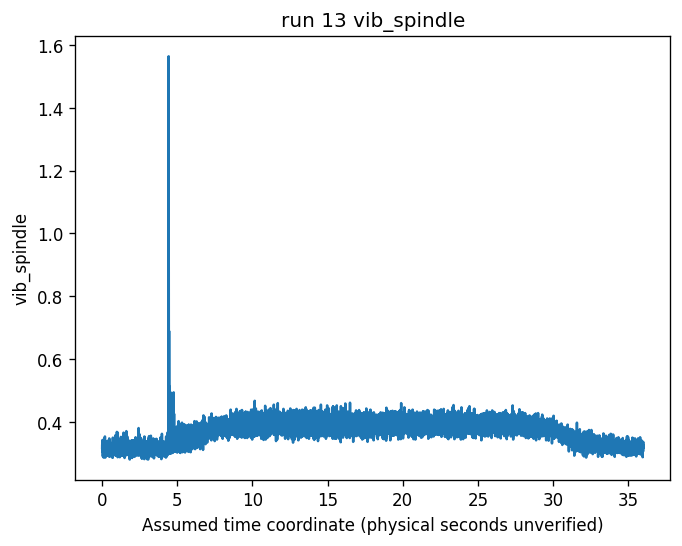

In [13]:
mill_13 = mill[0,12]["vib_spindle"]
print("run 13 vb=",mill[0,12]["VB"].item())

plt.plot(t_s,mill_13)
plt.title("run 13 vib_spindle")
plt.xlabel("Assumed time coordinate (physical seconds unverified)")
plt.ylabel("vib_spindle")
plt.show()


run 14 vb= 0.45


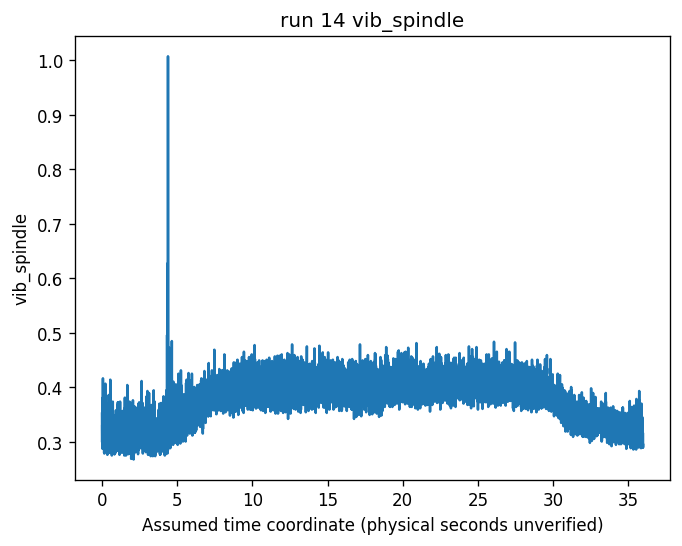

In [14]:
mill_14 = mill[0,13]["vib_spindle"]
print("run 14 vb=",mill[0,13]["VB"].item())

plt.plot(t_s,mill_14)
plt.title("run 14 vib_spindle")
plt.xlabel("Assumed time coordinate (physical seconds unverified)")
plt.ylabel("vib_spindle")
plt.show()


run 10 vb= 0.29


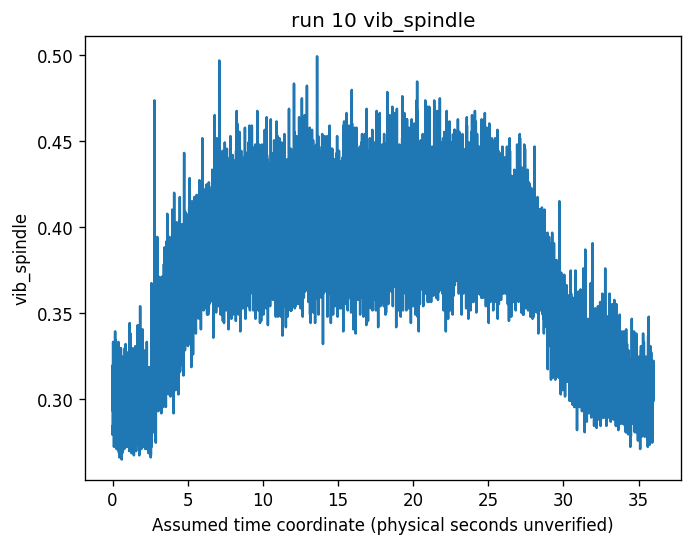

In [15]:
mill_10 = mill[0,9]["vib_spindle"]
print("run 10 vb=",mill[0,9]["VB"].item())

plt.plot(t_s,mill_10)
plt.title("run 10 vib_spindle")
plt.xlabel("Assumed time coordinate (physical seconds unverified)")
plt.ylabel("vib_spindle")
plt.show()


run 9 vb= 0.28


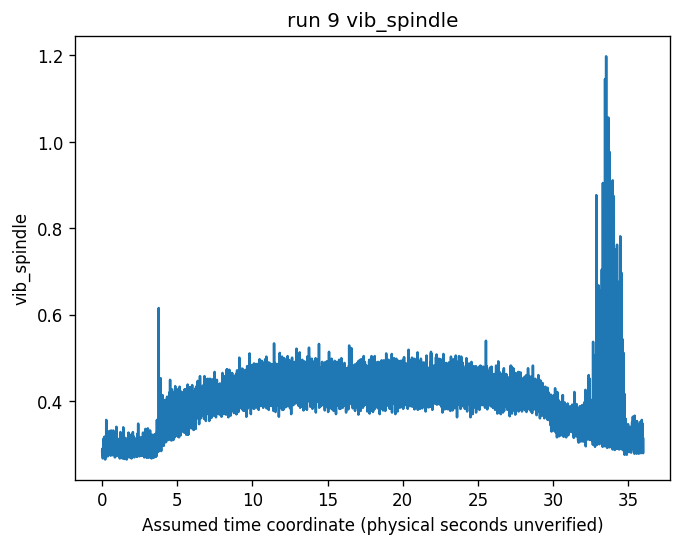

In [16]:
mill_9 = mill[0,8]["vib_spindle"]
print("run 9 vb=",mill[0,8]["VB"].item())

plt.plot(t_s,mill_9)
plt.title("run 9 vib_spindle")
plt.xlabel("Assumed time coordinate (physical seconds unverified)")
plt.ylabel("vib_spindle")
plt.show()


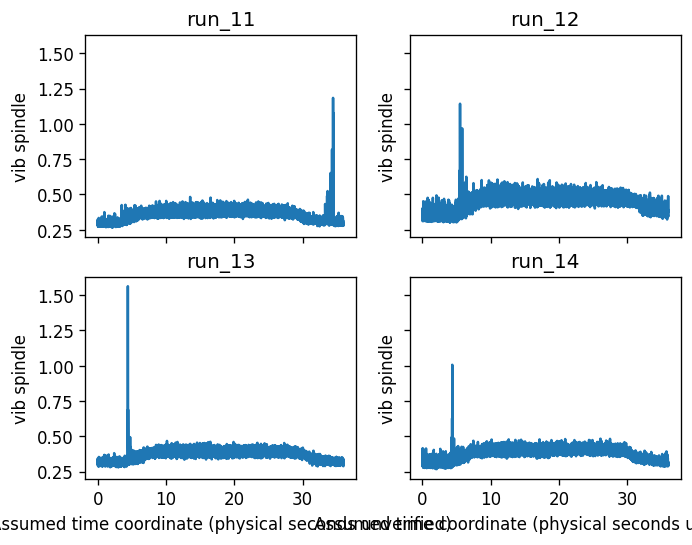

In [17]:
fig,axes = plt.subplots(2,2,sharex = True,sharey= True)
axes[0,0].plot(t_s,mill_11)
axes[0,0].set_ylabel("vib spindle")
axes[0,0].set_title("run_11")

axes[1,0].plot(t_s,mill_13)
axes[1,0].set_ylabel("vib spindle")
axes[1,0].set_title("run_13")
axes[1,0].set_xlabel("Assumed time coordinate (physical seconds unverified)")

axes[0,1].plot(t_s,mill_12)
axes[0,1].set_ylabel("vib spindle")
axes[0,1].set_title("run_12")

axes[1,1].plot(t_s,mill_14)
axes[1,1].set_ylabel("vib spindle")
axes[1,1].set_title("run_14")
axes[1,1].set_xlabel("Assumed time coordinate (physical seconds unverified)")


## 整理说明 / Editorial note: original grid and comments

The original loop and the commented-out checks are retained. Only the quotes surrounding the title f-string change for compatibility with Python versions before 3.12.

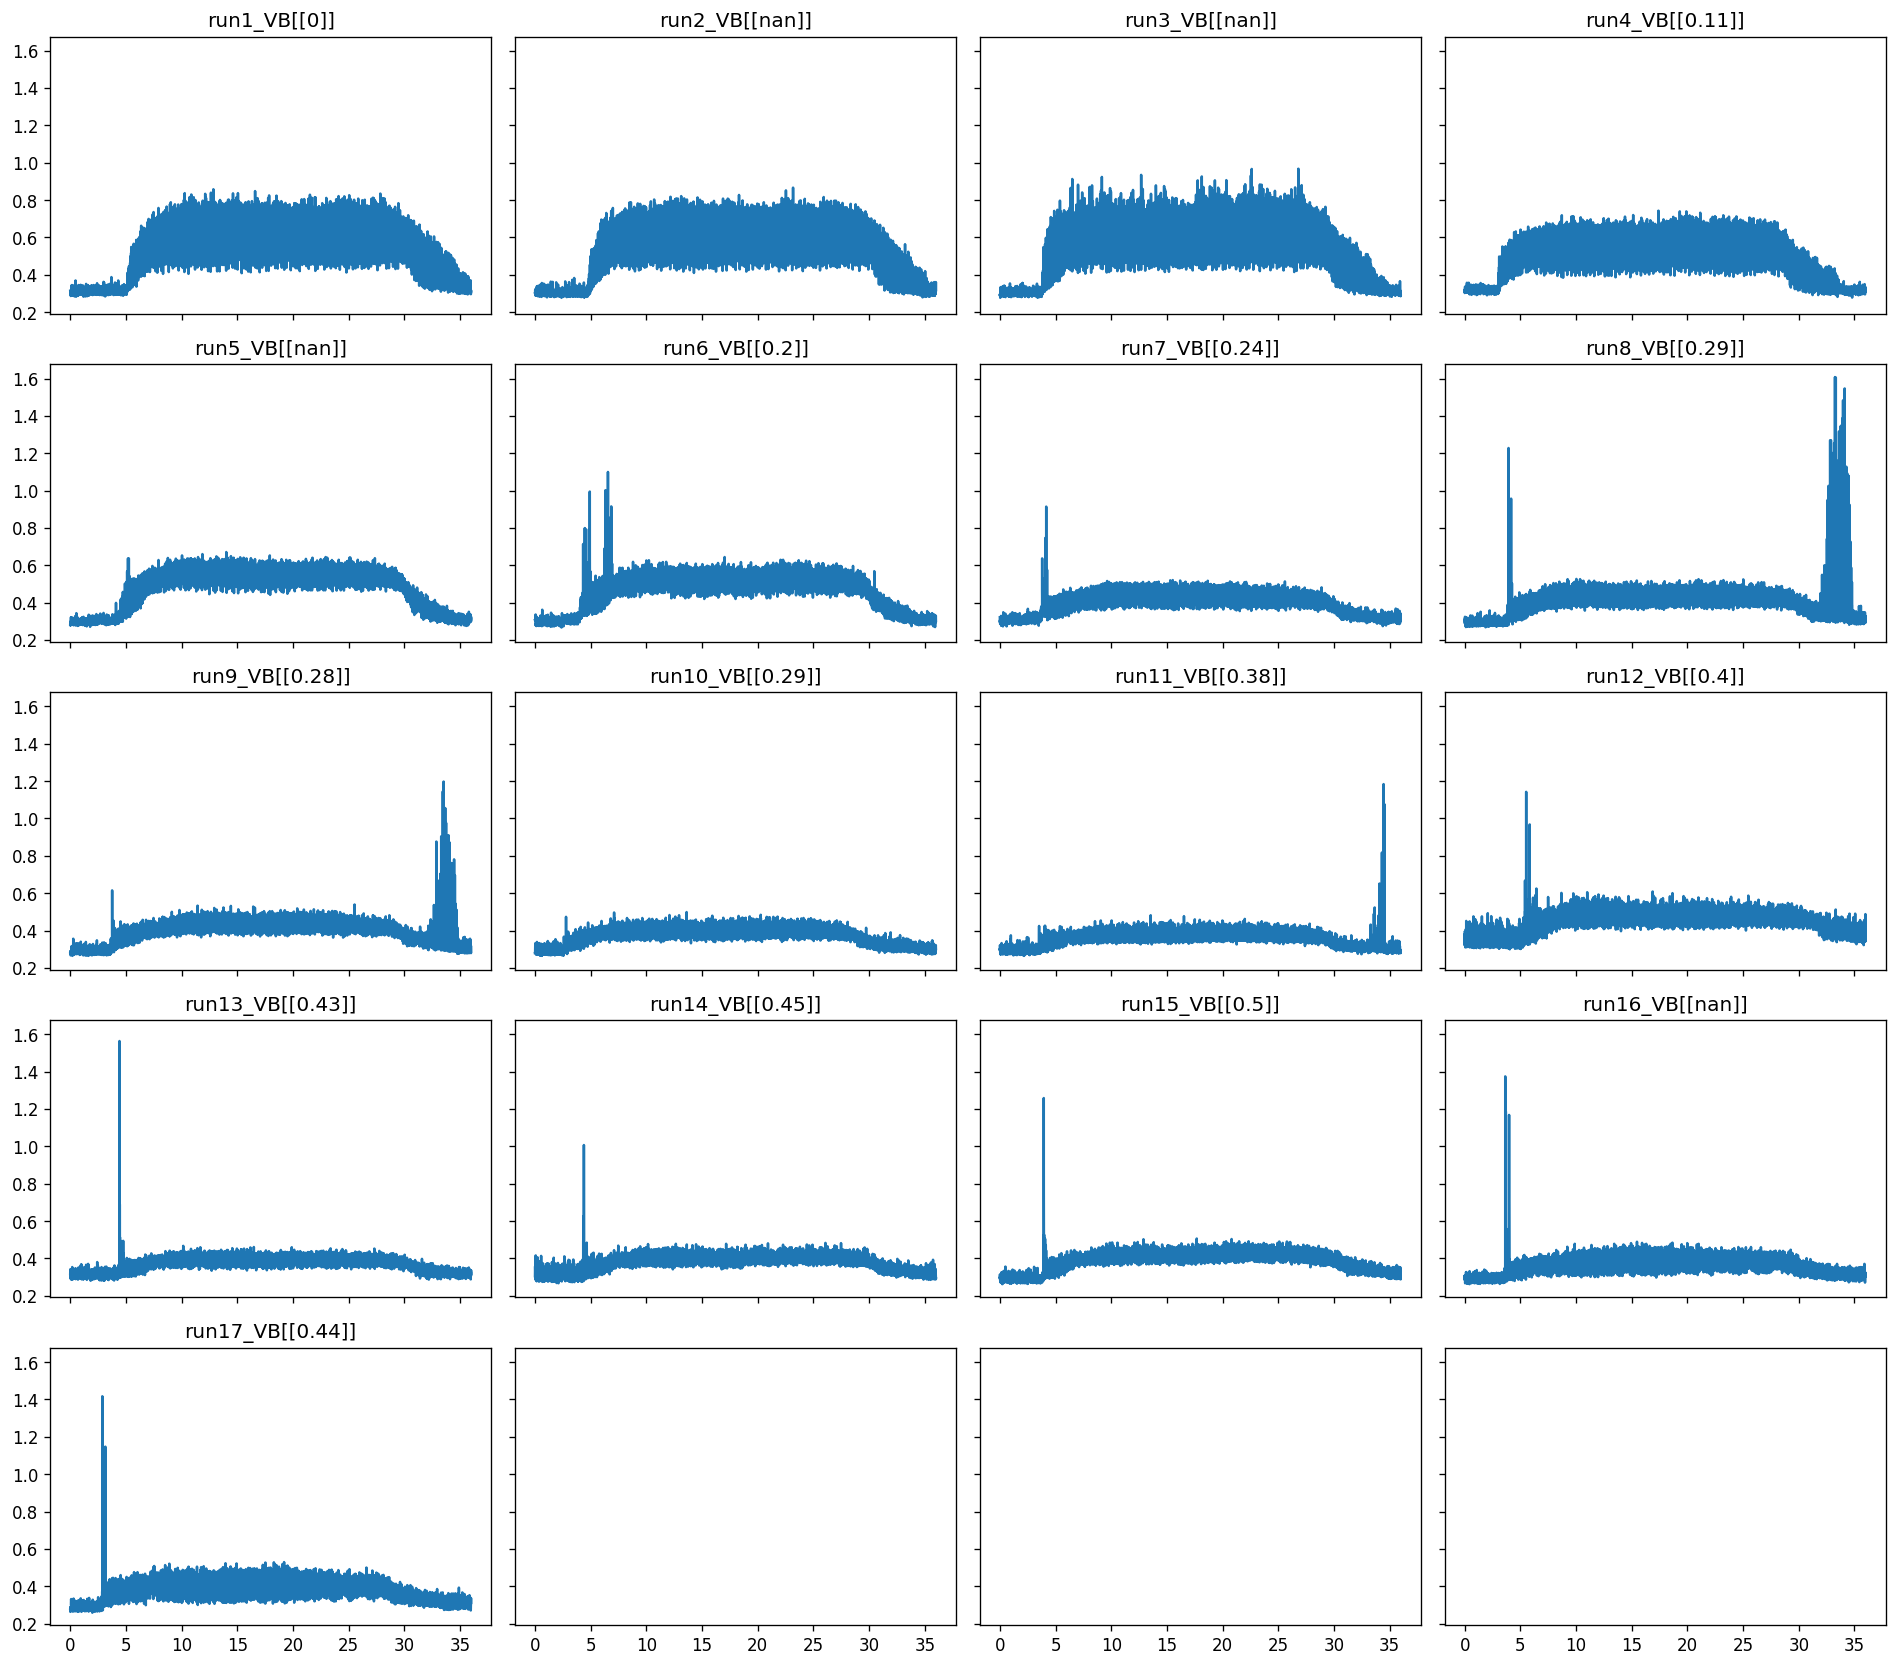

In [18]:
case_1_vib_s = []
for i in range(mill.shape[1]):
    run = mill[0, i]
    if run["case"].item() == 1:
     case_1_vib_s.append(i)
fig, axes = plt.subplots(5, 4, figsize=(16, 14),sharex=True, sharey=True)
for i in case_1_vib_s:
  run = mill[0, i]
  axes.flat[i].plot(t_s,run["vib_spindle"])
  axes.flat[i].set_title(f'run{i+1}_VB{run["VB"]}')
plt.tight_layout()
plt.show()
# print(case_1)
# print(len(case_1))


## 整理说明 / Editorial note: original exploratory axis choice

This original scatter plot puts VB on the horizontal axis and vibration mean on the vertical axis. The later publication comparison puts the input feature on the horizontal axis. Both views use the same observations; the fit below estimates VB from a feature.

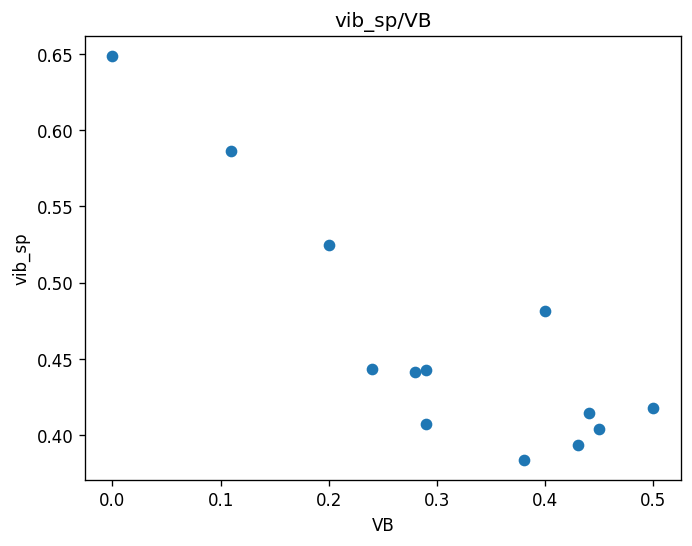

In [19]:
plt.scatter(VB_work,vib_spindle_cut_mean)
plt.title("vib_sp/VB")
plt.ylabel("vib_sp")
plt.xlabel("VB")
plt.show()


In [20]:
corr_matrix_mean = np.corrcoef(VB_work,vib_spindle_cut_mean)
#print(corr_matrix_mean)
r_mean = corr_matrix_mean[0,1]
print(r_mean)


-0.8626466487509021


use pearson correlation coefficient to discover linear relationship


In [21]:
std_run1 = np.std(mill[0,0]["vib_spindle"][mask_cut])
vib_spindle_cut_std = []
for i in number:
  run = mill[0,i-1]
  vib_spindle_std = np.std(run["vib_spindle"][mask_cut])
  vib_spindle_cut_std.append(vib_spindle_std)
print(np.array(vib_spindle_cut_std))


[0.07875024 0.06022453 0.03651107 0.03080332 0.03236167 0.02785777
 0.02558255 0.02387311 0.03550049 0.02102156 0.02223318 0.02386047
 0.03557258]


std for the run with VB recorded


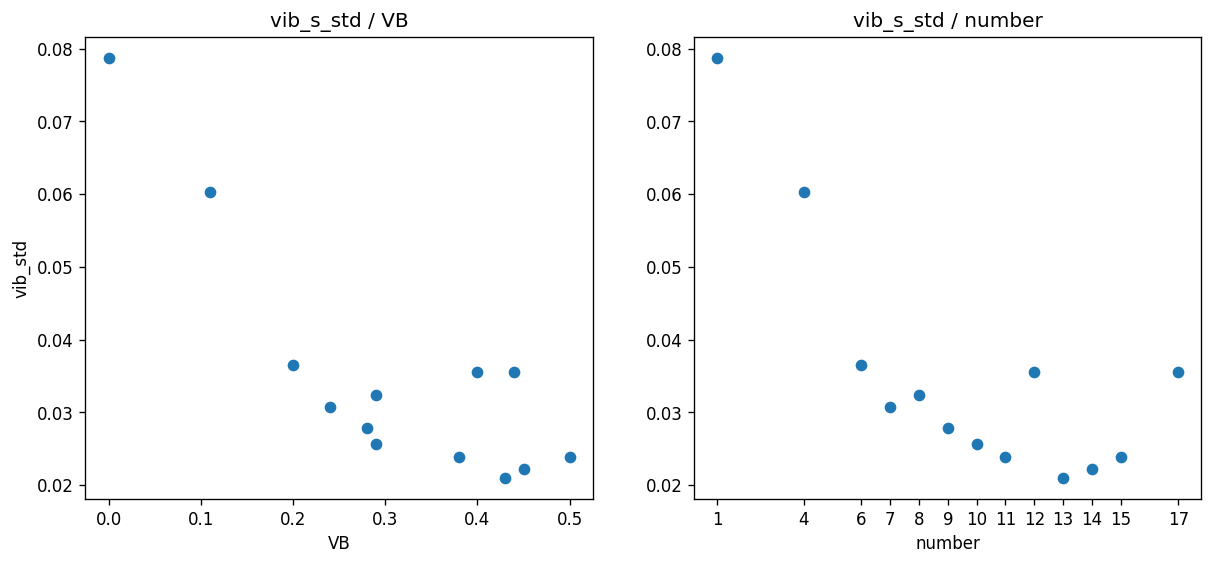

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(VB_work,vib_spindle_cut_std)
axes[0].set_title("vib_s_std / VB")
axes[0].set_ylabel("vib_std")
axes[0].set_xlabel("VB")

axes[1].scatter(number,vib_spindle_cut_std)
axes[1].set_title("vib_s_std / number")
axes[1].set_xlabel("number")
axes[1].set_xticks(number)


In [23]:
corrematrix_std = np.corrcoef(VB_work,vib_spindle_cut_std)
r_std = corrematrix_std[0,1]
print(r_std)


-0.8339148563427522


In [24]:
import pandas as pd

features_vib_sp = pd.DataFrame({
    "record_number": number,
    "VB": VB_work,
    "vib_mean": vib_spindle_cut_mean,
    "vib_std": vib_spindle_cut_std
})

display(features_vib_sp)


,record_number,VB,vib_mean,vib_std
0,1,0.00,0.648509,0.078750
1,4,0.11,0.586600,0.060225
2,6,0.20,0.524458,0.036511
3,7,0.24,0.443222,0.030803
4,8,0.29,0.442355,0.032362
5,9,0.28,0.441375,0.027858
6,10,0.29,0.407035,0.025583
7,11,0.38,0.383948,0.023873
8,12,0.40,0.481121,0.035500
9,13,0.43,0.393711,0.021022


## 整理说明 / Editorial note: the original mean baseline

These are the author-supplied `np.polyfit` calculations and variable names. The commented-out input experiment is retained in the next code cell. Signed residuals are measured VB minus fitted VB.

In [25]:
a_vibs = np.polyfit(vib_spindle_cut_mean,VB_work,1)[0]
b_vibs = np.polyfit(vib_spindle_cut_mean,VB_work,1)[1]
print(a_vibs,b_vibs)



-1.5680241088875106 1.0307383568702269


In [26]:
# vib_mean_input = float(input("mean spindle vibration = "))
# VB_est = a*vib_mean_input + b
# print(VB_est)

In [27]:
VB_est_vibs_mean = a_vibs * features_vib_sp["vib_mean"] + b_vibs
print(VB_est_vibs_mean)
print(features_vib_sp["VB"])
VB_residual_abs_vibs_mean = abs(features_vib_sp["VB"] - VB_est_vibs_mean)
print(VB_residual_abs_vibs_mean)
VB_residual_vibs_mean = features_vib_sp["VB"] - VB_est_vibs_mean
print(VB_residual_vibs_mean)

0     0.013861
1     0.110936
2     0.208376
3     0.335755
4     0.337116
5     0.338652
6     0.392497
7     0.428699
8     0.276329
9     0.413390
10    0.397200
11    0.375862
12    0.381327
Name: vib_mean, dtype: float64
0     0.00
1     0.11
2     0.20
3     0.24
4     0.29
5     0.28
6     0.29
7     0.38
8     0.40
9     0.43
10    0.45
11    0.50
12    0.44
Name: VB, dtype: float64
0     0.013861
1     0.000936
2     0.008376
3     0.095755
4     0.047116
5     0.058652
6     0.102497
7     0.048699
8     0.123671
9     0.016610
10    0.052800
11    0.124138
12    0.058673
dtype: float64
0    -0.013861
1    -0.000936
2    -0.008376
3    -0.095755
4    -0.047116
5    -0.058652
6    -0.102497
7    -0.048699
8     0.123671
9     0.016610
10    0.052800
11    0.124138
12    0.058673
dtype: float64


VB and its residual

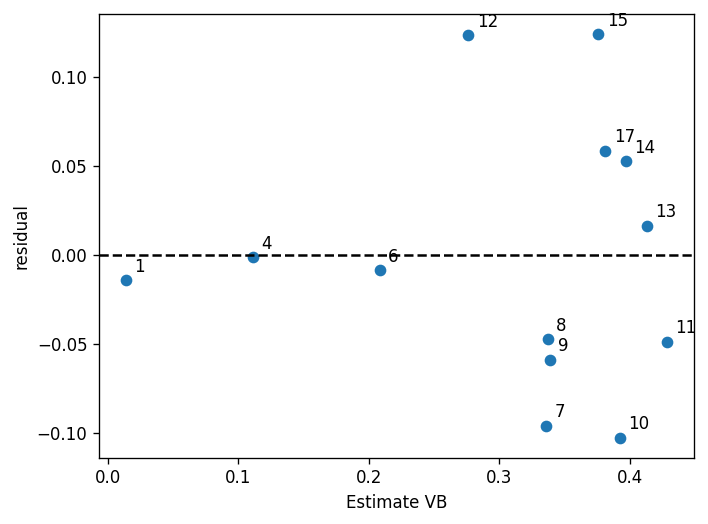

In [28]:
plt.scatter(VB_est_vibs_mean, VB_residual_vibs_mean)
plt.axhline(0, color="black", linestyle="--")
plt.ylabel("residual")
plt.xlabel("Estimate VB")

for n, x, y in zip(number, VB_est_vibs_mean, VB_residual_vibs_mean):
    plt.annotate(
        str(n),
        xy=(x, y),
        xytext=(5, 5),
        textcoords="offset points"
    )
plt.show()

Estimated VB by vib_spin mean - residual


## 整理说明 / Editorial note: what this residual plot means

This original plot puts vibration standard deviation against **residuals of the vibration mean model**. It is not the residual plot of the standard-deviation model, which is fitted in the next cells.

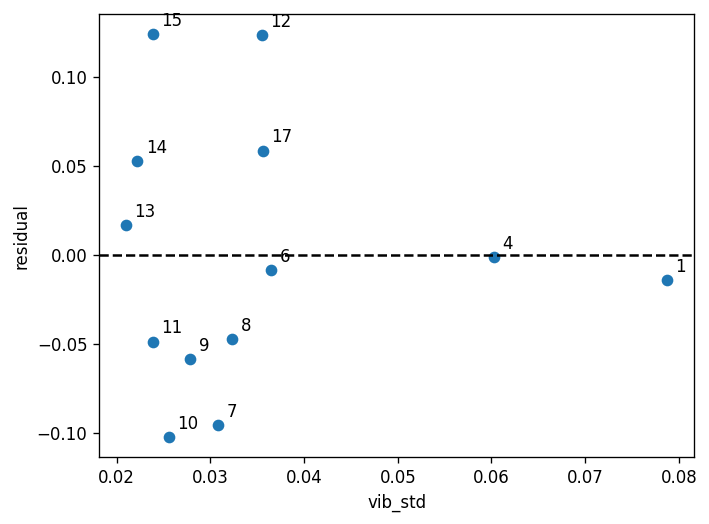

In [29]:
plt.scatter(features_vib_sp["vib_std"], VB_residual_vibs_mean)
plt.axhline(0, color="black", linestyle="--")
plt.ylabel("residual")
plt.xlabel("vib_std")

for n, x, y in zip(number, features_vib_sp["vib_std"], VB_residual_vibs_mean):
    plt.annotate(
        str(n),
        xy=(x, y),
        xytext=(5, 5),
        textcoords="offset points"
    )
plt.show()

## 整理说明 / Editorial note: one misleading print statement

The original `a_AEs` and `b_AEs` names are kept for comparison. In this cell they actually hold coefficients for **vibration standard deviation**, not AE. The final print is corrected to show those coefficients instead of `a_vibs` and `b_vibs`.

In [30]:
# [整理修正 / Print only] Keep a_AEs/b_AEs, but print the vibration-std fit.
a_AEs = np.polyfit(vib_spindle_cut_std,VB_work,1)[0]
b_AEs = np.polyfit(vib_spindle_cut_std,VB_work,1)[1]
print(a_AEs,b_AEs)



-7.301005635750568 0.5635207933821293


In [31]:
VB_est_vibs_std = a_AEs * features_vib_sp["vib_std"] + b_AEs
print(VB_est_vibs_std)
residual_vibs_std = features_vib_sp["VB"] - VB_est_vibs_std
print(residual_vibs_std)

0    -0.011435
1     0.123821
2     0.296953
3     0.338626
4     0.327248
5     0.360131
6     0.376742
7     0.389223
8     0.304332
9     0.410042
10    0.401196
11    0.389315
12    0.303805
Name: vib_std, dtype: float64
0     0.011435
1    -0.013821
2    -0.096953
3    -0.098626
4    -0.037248
5    -0.080131
6    -0.086742
7    -0.009223
8     0.095668
9     0.019958
10    0.048804
11    0.110685
12    0.136195
dtype: float64


estimated VB by vib_spin mean - residual

**整理说明 / Caption correction:** the original note immediately above says “mean”. The preceding calculation actually uses vibration **standard deviation**. The original note is kept visible rather than silently rewritten.

## 整理说明 / Editorial note: original AE exploration

The original AE mean, standard deviation, correlations and feature table follow. The original grid title has the same quote-only compatibility edit as the vibration grid.

AE_spindle analysis

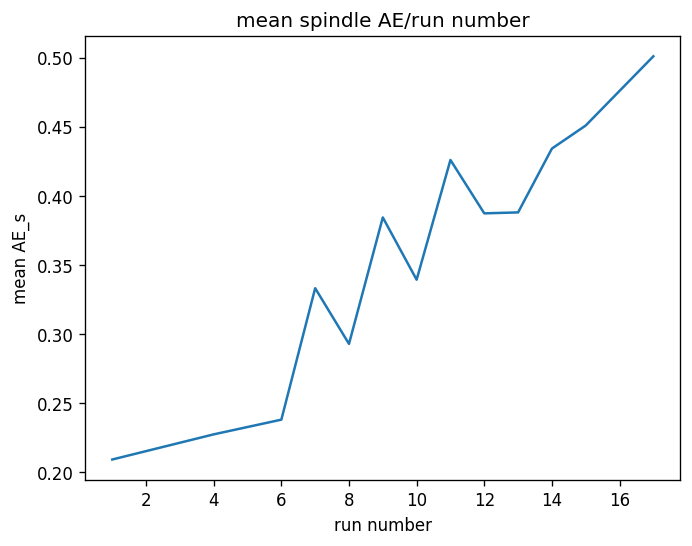

In [32]:
AE_spindle_cut_mean = []
for i in number:
  run = mill[0,i-1]
  AE_spindle_mean = np.mean(run["AE_spindle"][mask_cut])
  AE_spindle_cut_mean.append(AE_spindle_mean)

plt.plot(number,AE_spindle_cut_mean)
plt.title("mean spindle AE/run number")
plt.ylabel("mean AE_s")
plt.xlabel("run number")
plt.show()


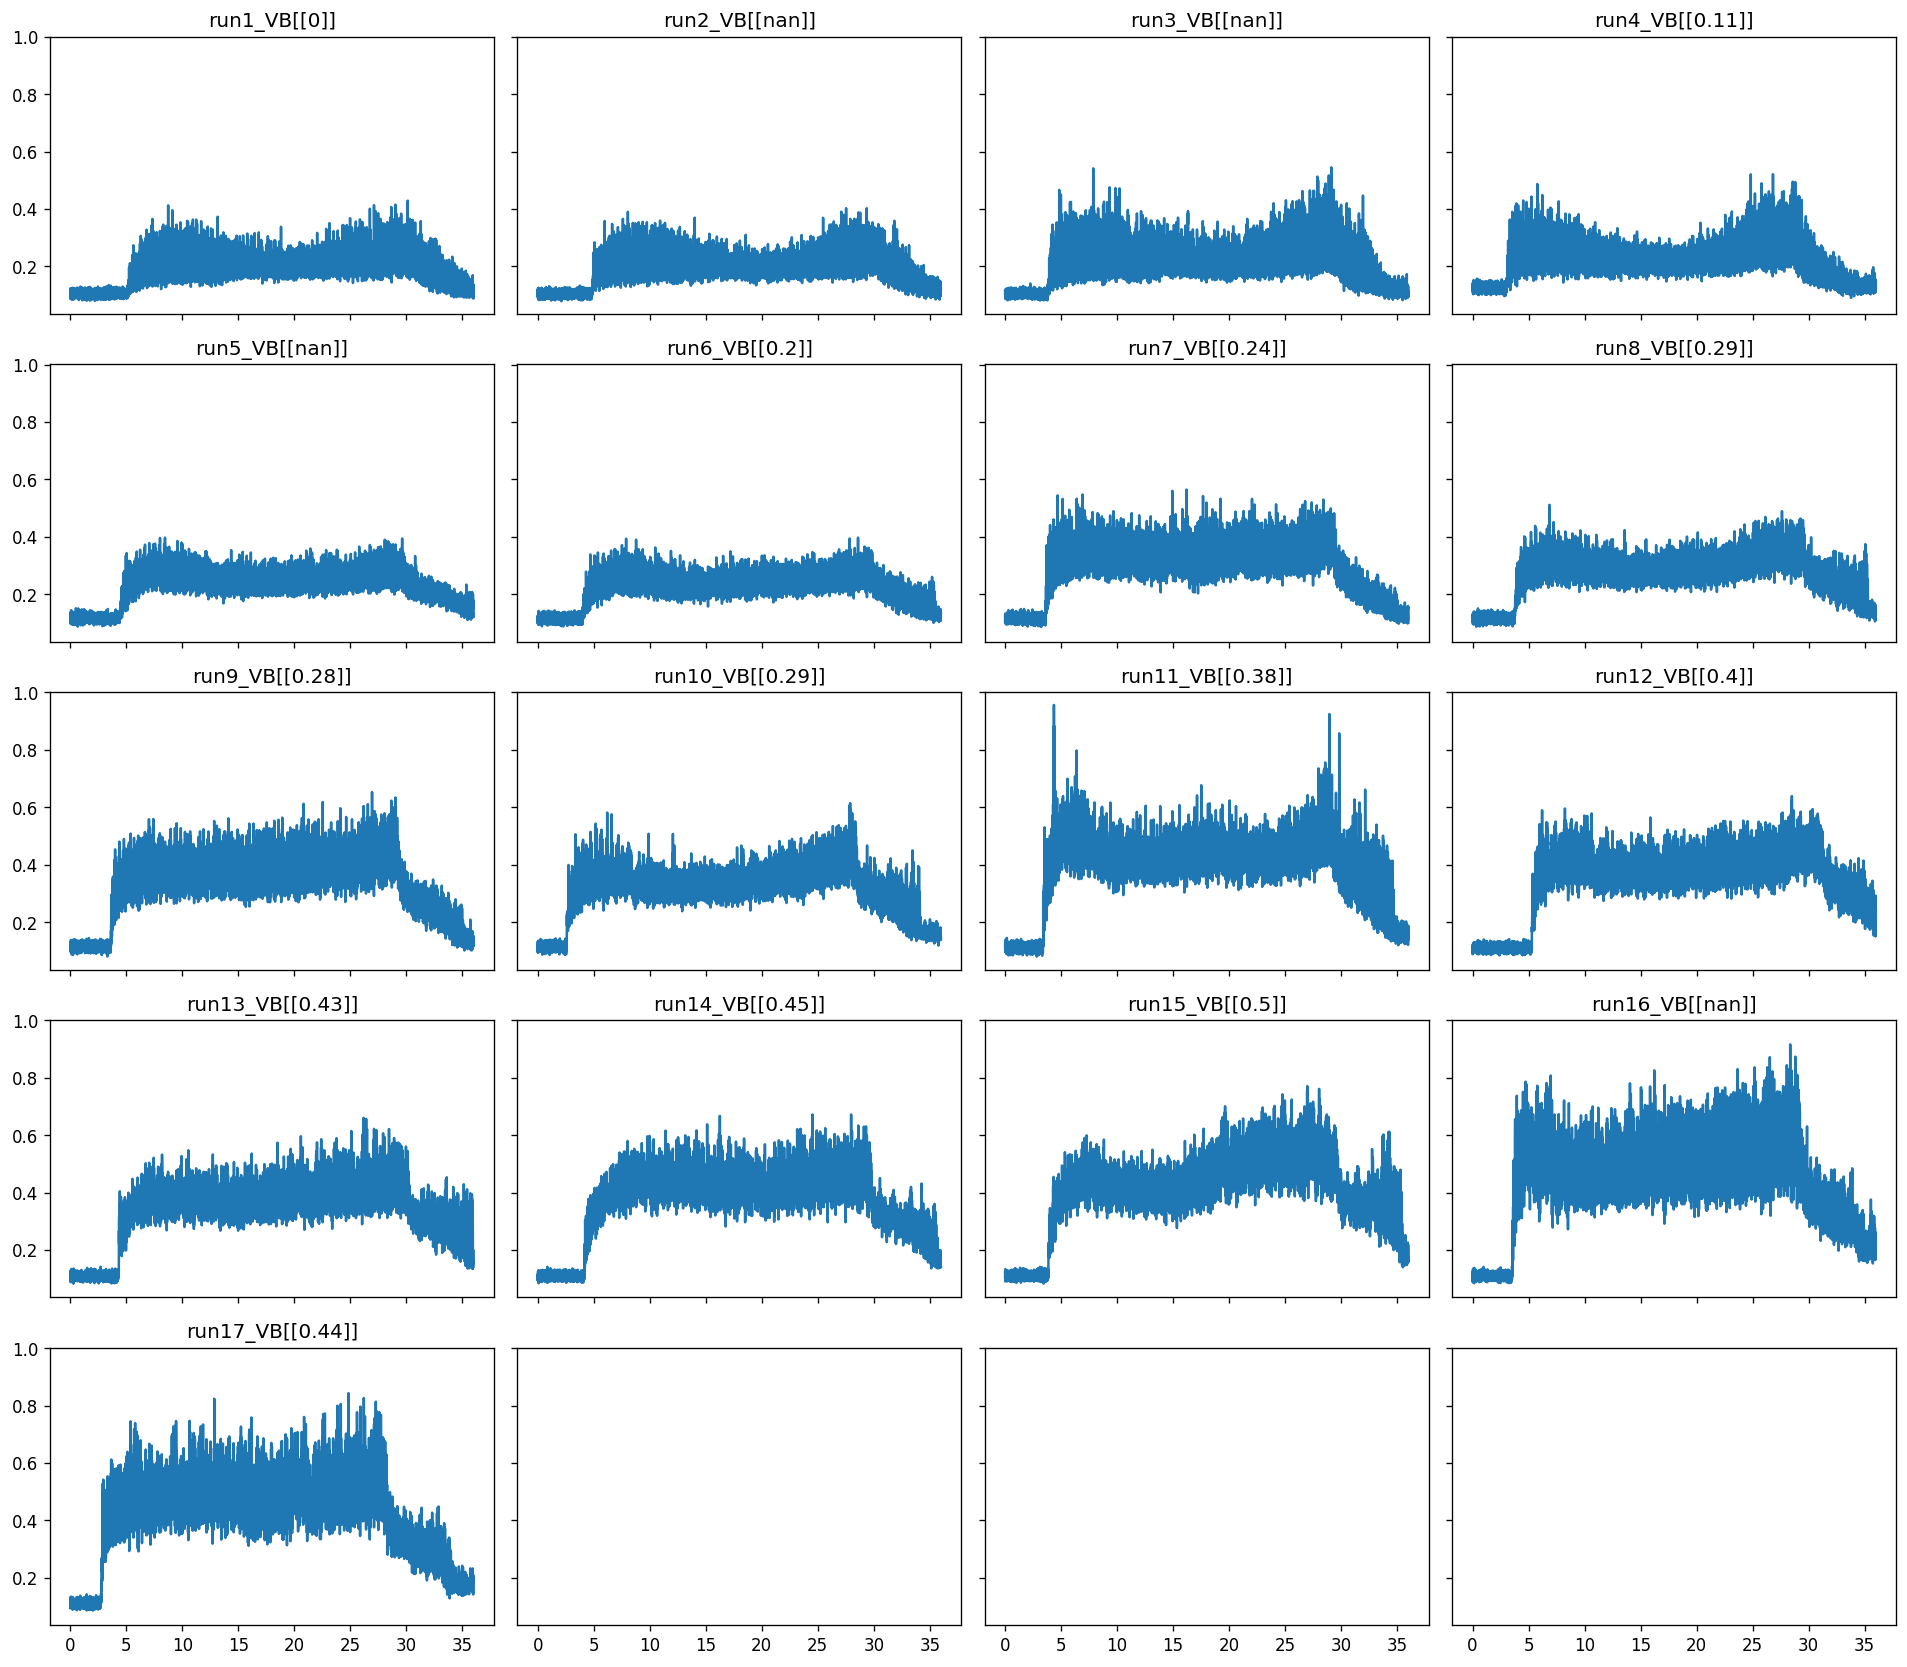

In [33]:
case_1_AE_sp = []
for i in range(mill.shape[1]):
    run = mill[0, i]
    if run["case"].item() == 1:
     case_1_AE_sp.append(i)
fig, axes = plt.subplots(5, 4, figsize=(16, 14),sharex=True, sharey=True)
for i in case_1_AE_sp:
  run = mill[0, i]
  axes.flat[i].plot(t_s,run["AE_spindle"])
  axes.flat[i].set_title(f'run{i+1}_VB{run["VB"]}')
plt.tight_layout()
plt.show()

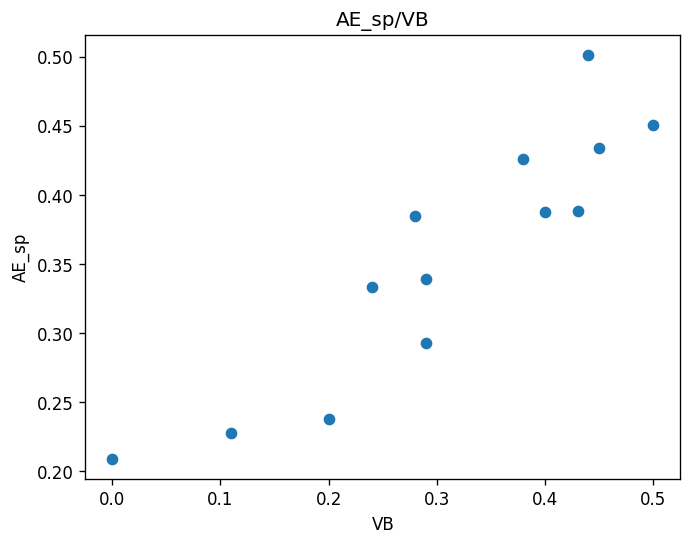

In [34]:
plt.scatter(VB_work,AE_spindle_cut_mean)
plt.title("AE_sp/VB")
plt.ylabel("AE_sp")
plt.xlabel("VB")
plt.show()

AE_spin_mean / VB

In [35]:
pearcorr_meanAE_spin = np.corrcoef(VB_work,AE_spindle_cut_mean)
print(pearcorr_meanAE_spin[0,1])

0.9113275145499792


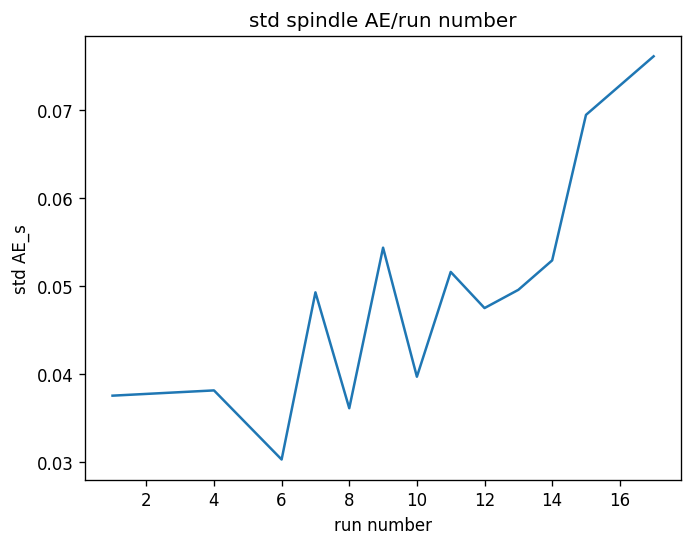

In [36]:
AE_spindle_cut_std = []
for i in number:
  run = mill[0,i-1]
  AE_spindle_std = np.std(run["AE_spindle"][mask_cut])
  AE_spindle_cut_std.append(AE_spindle_std)

plt.plot(number,AE_spindle_cut_std)
plt.title("std spindle AE/run number")
plt.ylabel("std AE_s")
plt.xlabel("run number")
plt.show()


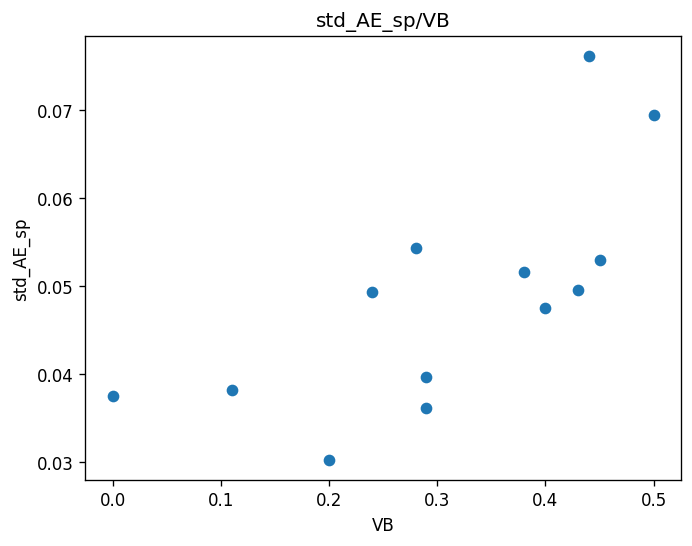

In [37]:
plt.scatter(VB_work,AE_spindle_cut_std)
plt.title("std_AE_sp/VB")
plt.ylabel("std_AE_sp")
plt.xlabel("VB")
plt.show()

## 整理说明 / Editorial note: reused correlation variable

The original variable `pearcorr_meanAE_spin` is reused here, but this cell calculates the correlation of **AE standard deviation** with VB. The code is retained; publication metrics later recompute and name each correlation explicitly.

In [38]:
pearcorr_meanAE_spin = np.corrcoef(VB_work,AE_spindle_cut_std)
print(pearcorr_meanAE_spin[0,1])

0.7037997344327613


In [39]:
features_AE_sp = pd.DataFrame({
    "record_number": number,
    "VB": VB_work,
    "AE_mean": AE_spindle_cut_mean,
    "AE_std": AE_spindle_cut_std
})

display(features_AE_sp)


,record_number,VB,AE_mean,AE_std
0,1,0.00,0.209068,0.037541
1,4,0.11,0.227271,0.038139
2,6,0.20,0.237914,0.030290
3,7,0.24,0.333051,0.049276
4,8,0.29,0.292756,0.036115
5,9,0.28,0.384274,0.054352
6,10,0.29,0.339209,0.039691
7,11,0.38,0.425877,0.051597
8,12,0.40,0.387235,0.047492
9,13,0.43,0.387914,0.049563


# 整理补充 / Publication additions

**Everything from this heading onwards is added during publication preparation with ChatGPT assistance.** It is not present in the supplied notebook. The feature arrays, vibration mean fit and vibration standard-deviation fit are reused directly from the author's cells above.

The later screenshots supplied by the author show an AE mean fit and MAEs. That code is not in the supplied notebook, so the AE fit is explicitly added below to reproduce those results. A newer Colab notebook can replace this reconstruction when supplied.


In [40]:
# [整理补充 / Added code] AE mean baseline corresponding to the later result screenshots.
a_AE_mean = np.polyfit(AE_spindle_cut_mean, VB_work, 1)[0]
b_AE_mean = np.polyfit(AE_spindle_cut_mean, VB_work, 1)[1]
VB_est_AEs_mean = a_AE_mean * features_AE_sp['AE_mean'] + b_AE_mean
VB_residual_AEs_mean = features_AE_sp['VB'] - VB_est_AEs_mean

MAE_vibs_mean = np.mean(abs(VB_residual_vibs_mean))
MAE_vibs_std = np.mean(abs(residual_vibs_std))
MAE_AEs_mean = np.mean(abs(VB_residual_AEs_mean))
print('Vibration mean fit MAE:', MAE_vibs_mean)
print('Vibration std fit MAE:', MAE_vibs_std)
print('AE mean fit MAE:', MAE_AEs_mean)
print('All MAEs are in-sample. No held-out evaluation has been performed.')


Vibration mean fit MAE: 0.05782947882112705
Vibration std fit MAE: 0.06503763390574346
AE mean fit MAE: 0.05107716919510518
All MAEs are in-sample. No held-out evaluation has been performed.


## 整理补充 / Export the existing arrays

This cell turns the earlier feature tables, coefficients and residuals into files for readers. It also checks the record/run labels. It does not introduce a combined model or change the earlier feature calculations.


In [41]:
# [整理补充 / Added exports] Reuse the arrays and coefficients from the original learning cells.
import hashlib
import json

run_ids = [int(mill[0, n-1]['run'].item()) for n in number]
assert run_ids == number, 'Global record numbers differ from run IDs; check labels.'

features = features_vib_sp.merge(features_AE_sp, on=['record_number', 'VB'], validate='one_to_one')
features.insert(1, 'case', 1)
features.insert(2, 'run', run_ids)

metrics = pd.DataFrame([
    {'feature': 'vib_mean', 'pearson_r': np.corrcoef(vib_spindle_cut_mean, VB_work)[0, 1],
     'slope': a_vibs, 'intercept': b_vibs, 'fit_MAE': MAE_vibs_mean},
    {'feature': 'vib_std', 'pearson_r': np.corrcoef(vib_spindle_cut_std, VB_work)[0, 1],
     'slope': a_AEs, 'intercept': b_AEs, 'fit_MAE': MAE_vibs_std},
    {'feature': 'AE_mean', 'pearson_r': np.corrcoef(AE_spindle_cut_mean, VB_work)[0, 1],
     'slope': a_AE_mean, 'intercept': b_AE_mean, 'fit_MAE': MAE_AEs_mean},
])
metrics['evaluation'] = 'in-sample; no independent test set'

residuals = features[['record_number', 'case', 'run', 'VB']].copy()
for name, estimated, residual in [
    ('vib_mean', VB_est_vibs_mean, VB_residual_vibs_mean),
    ('vib_std', VB_est_vibs_std, residual_vibs_std),
    ('AE_mean', VB_est_AEs_mean, VB_residual_AEs_mean),
]:
    residuals[name + '_estimate'] = np.asarray(estimated)
    residuals[name + '_residual'] = np.asarray(residual)

(ROOT / 'results').mkdir(parents=True, exist_ok=True)
features.to_csv(ROOT / 'results/case1_features.csv', index=False)
metrics.to_csv(ROOT / 'results/baseline_metrics.csv', index=False)
residuals.to_csv(ROOT / 'results/case1_residuals.csv', index=False)

provenance = {
    'dataset_shape': list(mill.shape), 'case': 1,
    'labelled_records': len(number), 'retains_zero_VB': True,
    'window_fraction': [10 / 36, 25 / 36],
    'window_boundary': 'strictly greater / strictly less',
    'window_indices_zero_based': [int(np.flatnonzero(mask_cut)[0]), int(np.flatnonzero(mask_cut)[-1])],
    'std_ddof': 0,
    'time_axis': 'Original 36-second assumption is unverified; publication waveform uses sample indices.',
    'data_sha256': hashlib.sha256(DATA_PATH.read_bytes()).hexdigest(),
    'evaluation': 'in-sample; no held-out data',
    'primary_analysis': 'notebooks/01_case1_exploration.ipynb; original learning cells plus labelled publication additions',
    'supplied_original': 'notebooks/Mill_phase_2_Fixed.ipynb',
}
original_file = ROOT / 'notebooks/Mill_phase_2_Fixed.ipynb'
if original_file.is_file():
    provenance['supplied_original_sha256'] = hashlib.sha256(original_file.read_bytes()).hexdigest()
(ROOT / 'results/provenance.json').write_text(json.dumps(provenance, indent=2) + '\n')
display(features)
display(metrics)


,record_number,case,run,VB,vib_mean,vib_std,AE_mean,AE_std
0,1,1,1,0.00,0.648509,0.078750,0.209068,0.037541
1,4,1,4,0.11,0.586600,0.060225,0.227271,0.038139
2,6,1,6,0.20,0.524458,0.036511,0.237914,0.030290
3,7,1,7,0.24,0.443222,0.030803,0.333051,0.049276
4,8,1,8,0.29,0.442355,0.032362,0.292756,0.036115
5,9,1,9,0.28,0.441375,0.027858,0.384274,0.054352
6,10,1,10,0.29,0.407035,0.025583,0.339209,0.039691
7,11,1,11,0.38,0.383948,0.023873,0.425877,0.051597
8,12,1,12,0.40,0.481121,0.035500,0.387235,0.047492
9,13,1,13,0.43,0.393711,0.021022,0.387914,0.049563


,feature,pearson_r,slope,intercept,fit_MAE,evaluation
0,vib_mean,-0.862647,-1.568024,1.030738,0.057829,in-sample; no independent test set
1,vib_std,-0.833915,-7.301006,0.563521,0.065038,in-sample; no independent test set
2,AE_mean,0.911328,1.449900,-0.205738,0.051077,in-sample; no independent test set


## 整理补充 / Publication comparison and label positions

This figure is a new presentation of the original feature arrays. The dictionary below controls the crowded labels. The first offset moves the label left/right and the second down/up, measured in typographic points rather than data units. Leader lines help connect displaced labels to their observations. The points and fit coefficients stay the same.

Reference: [Matplotlib `annotate`](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.annotate.html).


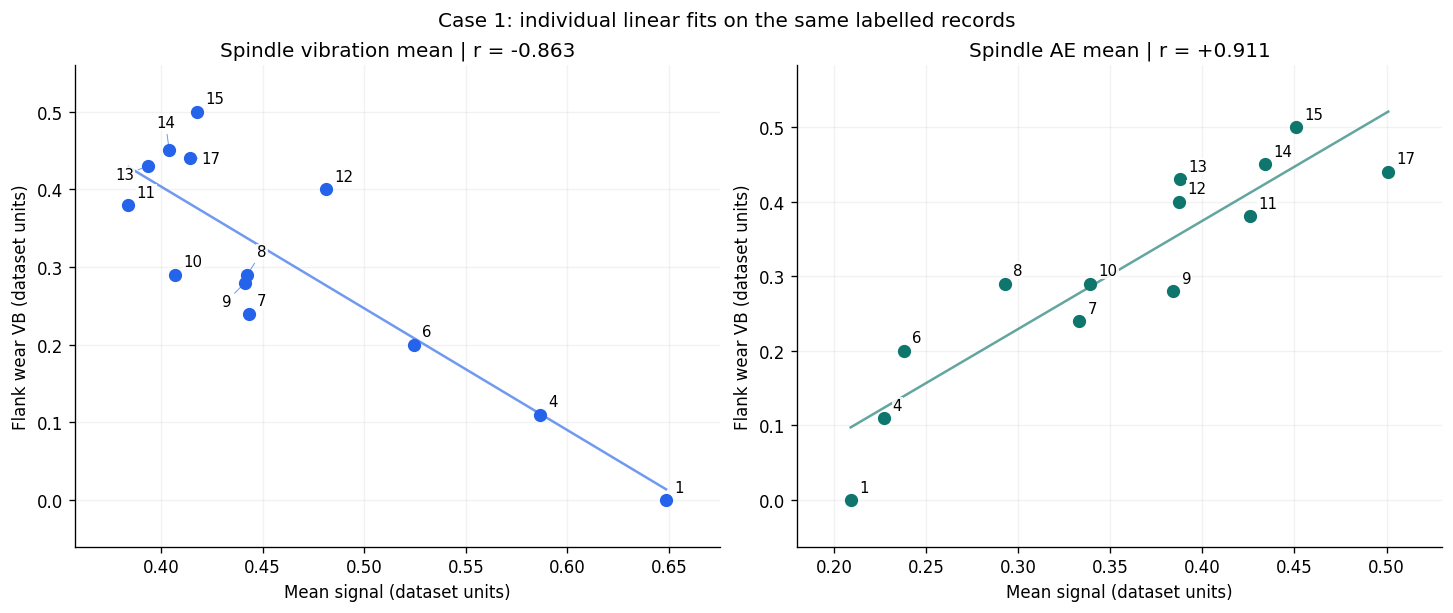

In [42]:
# [整理补充 / Added plot] Reuse the author's means and original vibration-fit coefficients.
label_offsets = {
    'vib_mean': {8: (6, 11), 9: (-14, -14), 13: (-20, -8), 14: (-8, 14), 17: (7, -3)},
    'AE_mean': {},
}

colors = {'vib_mean': '#2563eb', 'AE_mean': '#0f766e'}
fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
for ax, feature, values, a, b, title in zip(
    axes, ['vib_mean', 'AE_mean'], [vib_spindle_cut_mean, AE_spindle_cut_mean],
    [a_vibs, a_AE_mean], [b_vibs, b_AE_mean],
    ['Spindle vibration mean', 'Spindle AE mean'],
):
    ax.scatter(values, VB_work, color=colors[feature], s=48, zorder=3)
    x = np.linspace(min(values), max(values), 100)
    ax.plot(x, a * x + b, color=colors[feature], alpha=0.65)

    for n, xx, yy in zip(run_ids, values, VB_work):
        offset = label_offsets[feature].get(n, (5, 5))
        leader = ({'arrowstyle': '-', 'color': colors[feature], 'lw': 0.6, 'alpha': 0.65}
                  if n in label_offsets[feature] else None)
        ax.annotate(str(n), xy=(xx, yy), xytext=offset, textcoords='offset points',
                    fontsize=9, arrowprops=leader,
                    bbox={'facecolor': 'white', 'edgecolor': 'none', 'alpha': 0.85, 'pad': 0.5})

    r = np.corrcoef(values, VB_work)[0, 1]
    ax.set(title=f'{title} | r = {r:+.3f}', xlabel='Mean signal (dataset units)',
           ylabel='Flank wear VB (dataset units)')
    ax.margins(x=0.10, y=0.12)
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(alpha=0.16)

fig.suptitle('Case 1: individual linear fits on the same labelled records')
(ROOT / 'figures').mkdir(parents=True, exist_ok=True)
fig.savefig(ROOT / 'figures/feature_relationships.png', dpi=220)
plt.show()


## 整理补充 / Side-by-side residuals

The vibration mean residual is reused from the original code. AE mean residuals come from the labelled addition above. Both are calculated on the same observations used for fitting; neither is an independent test error.


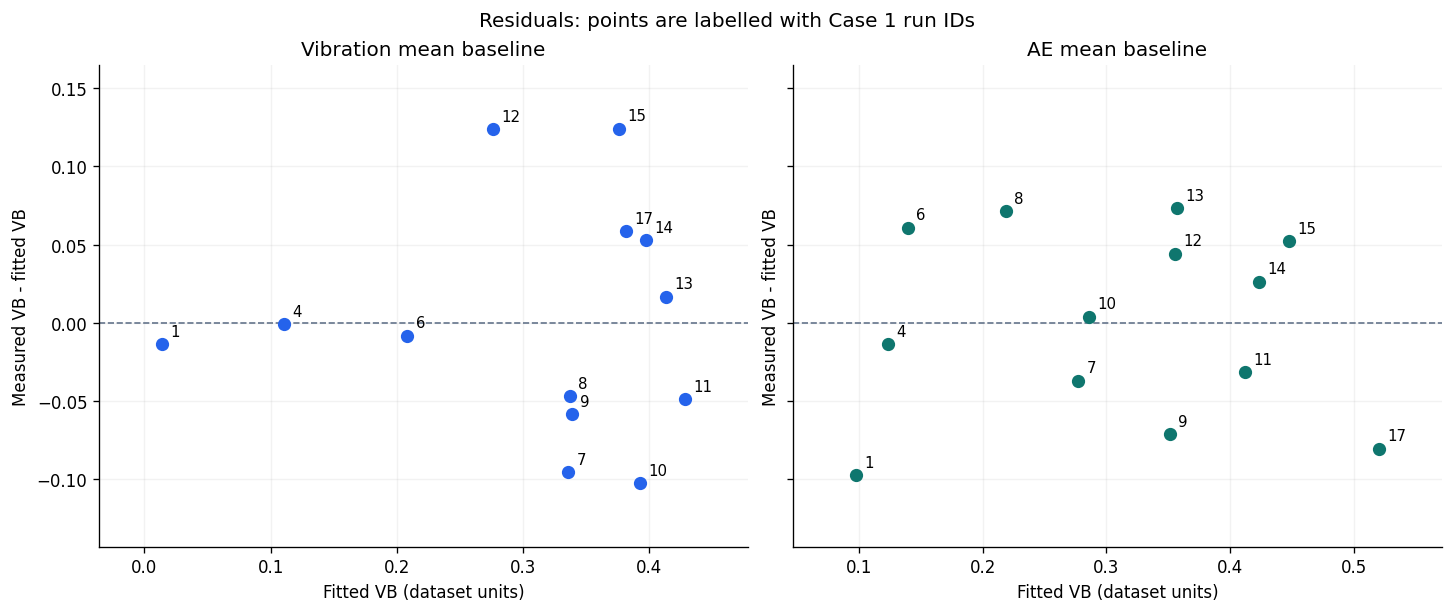

In [43]:
# [整理补充 / Added comparison] The vibration residual calculation above is unchanged.
fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True, sharey=True)
for ax, feature, estimated, residual, title in zip(
    axes, ['vib_mean', 'AE_mean'], [VB_est_vibs_mean, VB_est_AEs_mean],
    [VB_residual_vibs_mean, VB_residual_AEs_mean], ['Vibration mean baseline', 'AE mean baseline'],
):
    ax.axhline(0, color='#64748b', linestyle='--', linewidth=1)
    ax.scatter(estimated, residual, color=colors[feature], s=48, zorder=3)
    for n, xx, yy in zip(run_ids, estimated, residual):
        ax.annotate(str(n), xy=(xx, yy), xytext=(5, 5), textcoords='offset points', fontsize=9)
    ax.set(title=title, xlabel='Fitted VB (dataset units)', ylabel='Measured VB - fitted VB')
    ax.margins(x=0.12, y=0.18)
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(alpha=0.16)
fig.suptitle('Residuals: points are labelled with Case 1 run IDs')
fig.savefig(ROOT / 'figures/residual_comparison.png', dpi=220)
plt.show()


## 整理补充 / Signal-window illustration

This added presentation uses the same raw records and the unchanged `mask_cut`. The horizontal coordinate is a sample index, because the physical time scale remains unverified.


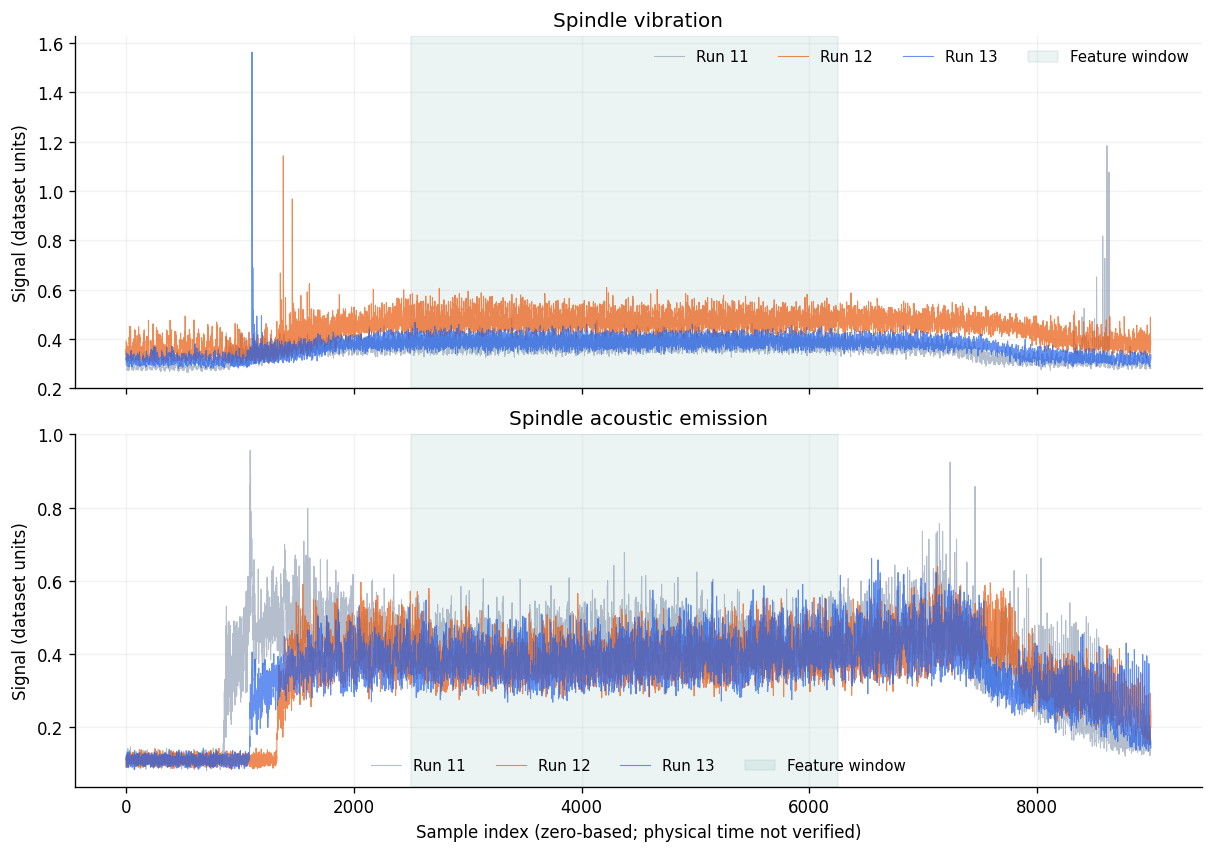

In [44]:
# [整理补充 / Added plot] Illustrate the original feature window without asserting seconds.
fig, axes = plt.subplots(2, 1, figsize=(10, 7), constrained_layout=True, sharex=True)
for ax, channel, title in zip(axes, ['vib_spindle', 'AE_spindle'],
                              ['Spindle vibration', 'Spindle acoustic emission']):
    for n, color in [(11, '#94a3b8'), (12, '#ea580c'), (13, '#2563eb')]:
        signal = mill[0, n-1][channel].ravel()
        ax.plot(np.arange(len(signal)), signal, color=color, linewidth=0.65,
                alpha=0.7, label=f'Run {n}')
    window_indices = np.flatnonzero(mask_cut)
    ax.axvspan(window_indices[0], window_indices[-1], color='#0f766e', alpha=0.08,
               label='Feature window')
    ax.set(title=title, ylabel='Signal (dataset units)')
    ax.legend(ncol=4, frameon=False, fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(alpha=0.16)
axes[-1].set_xlabel('Sample index (zero-based; physical time not verified)')
fig.savefig(ROOT / 'figures/signal_window.png', dpi=220)
plt.show()


## Personal reflection / 我的感悟

<!-- Add your own reflection here. This section is intentionally left blank. -->

## Planned work

Try a combined mean-feature baseline, then test whether standard deviation adds useful information. Evaluate on data kept separate from fitting before considering more complex models. These steps are planned, not completed.
